In [7]:
from pathlib import Path
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [8]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Použité zariadenie:", device)

Použité zariadenie: cpu


In [9]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_DIR = PROJECT_ROOT / "classification" / "train"
VAL_DIR   = PROJECT_ROOT / "classification" / "val"
TEST_DIR  = PROJECT_ROOT / "classification" / "test"


print("TRAIN:", TRAIN_DIR)
print("VAL  :", VAL_DIR)
print("TEST :", TEST_DIR)

TRAIN: c:\CNN\TP_detekcia_defektov\classification\train
VAL  : c:\CNN\TP_detekcia_defektov\classification\val
TEST : c:\CNN\TP_detekcia_defektov\classification\test


In [10]:
raw_train_dataset = datasets.ImageFolder(TRAIN_DIR)
raw_test_dataset = datasets.ImageFolder(TEST_DIR)

print("Triedy:", raw_train_dataset.classes)
print("Mapovanie tried:", raw_train_dataset.class_to_idx)
print("Počet obrázkov v train:", len(raw_train_dataset))
print("Počet obrázkov v test:", len(raw_test_dataset))

Triedy: ['bad1', 'bad2', 'bad3', 'bad4', 'good']
Mapovanie tried: {'bad1': 0, 'bad2': 1, 'bad3': 2, 'bad4': 3, 'good': 4}
Počet obrázkov v train: 1260
Počet obrázkov v test: 111


In [69]:
IMG_SIZE = 128
BATCH_SIZE = 32

##jednokanalovy

#train_transform = transforms.Compose([
 #   transforms.Grayscale(num_output_channels=1),
  #  transforms.Resize((IMG_SIZE, IMG_SIZE)),
   # transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5], std=[0.5])
#])
  
##trojkanalovy

#train_transform = transforms.Compose([
 #   transforms.Grayscale(num_output_channels=3),
  #  transforms.Resize((IMG_SIZE, IMG_SIZE)),
   # transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5, 0.5, 0.5],
     #                    std=[0.5, 0.5, 0.5])
#])

#RGB

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])


eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [70]:
full_train_for_split = datasets.ImageFolder(TRAIN_DIR)

train_size = int(0.8 * len(full_train_for_split))
val_size = len(full_train_for_split) - train_size

train_subset, val_subset = random_split(
    full_train_for_split,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_indices = train_subset.indices
val_indices = val_subset.indices

train_dataset = Subset(datasets.ImageFolder(TRAIN_DIR, transform=train_transform), train_indices)
val_dataset = Subset(datasets.ImageFolder(TRAIN_DIR, transform=eval_transform), val_indices)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

class_names = datasets.ImageFolder(TRAIN_DIR).classes

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))
print("Classes:", class_names)

Train: 1008
Val: 252
Test: 111
Classes: ['bad1', 'bad2', 'bad3', 'bad4', 'good']


In [71]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

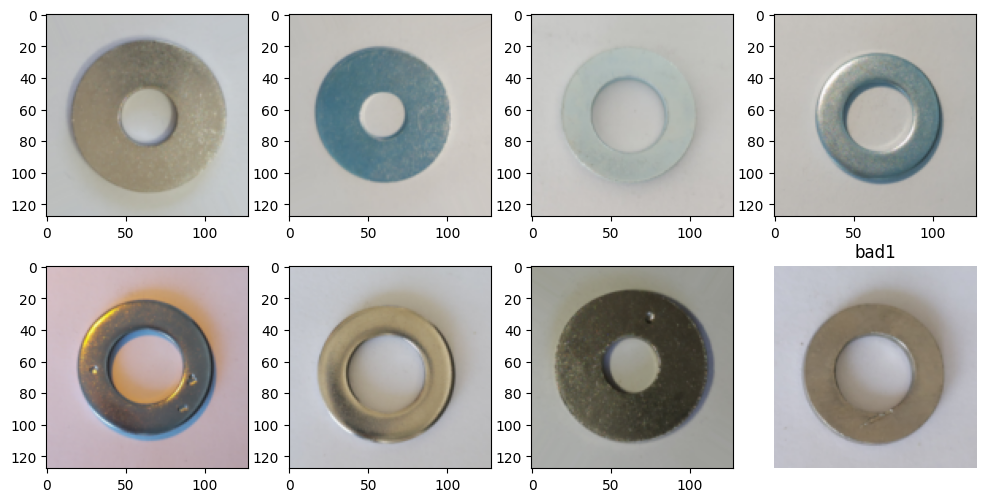

In [72]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    
    img = images[i].cpu()

    # denormalizácia
    img = img * 0.5 + 0.5

    img = img.permute(1, 2, 0).numpy()

    # ak je to "falošné RGB" (3 rovnaké kanály), zobrazíme ako gray
    if img.shape[2] == 1 or np.allclose(img[..., 0], img[..., 1]):
        plt.imshow(img[..., 0], cmap="gray")
    else:
        plt.imshow(img)

plt.title(class_names[labels[i].item()])
plt.axis("off")


In [73]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), #pri trojkanalovom 3, pri jednokanalovom 1
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = SimpleCNN(num_classes=len(class_names)).to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)


In [74]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [75]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [76]:
EPOCHS = 15

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

model.load_state_dict(best_model_state)

Epoch 1/15 | train_loss=1.3327, train_acc=0.5099 | val_loss=1.2722, val_acc=0.5317
Epoch 2/15 | train_loss=1.0828, train_acc=0.6270 | val_loss=1.3964, val_acc=0.5198
Epoch 3/15 | train_loss=0.9749, train_acc=0.6587 | val_loss=1.0975, val_acc=0.6032
Epoch 4/15 | train_loss=0.8512, train_acc=0.6954 | val_loss=0.9786, val_acc=0.6548
Epoch 5/15 | train_loss=0.7795, train_acc=0.7163 | val_loss=0.9952, val_acc=0.6706
Epoch 6/15 | train_loss=0.7051, train_acc=0.7579 | val_loss=1.1406, val_acc=0.6270
Epoch 7/15 | train_loss=0.6957, train_acc=0.7470 | val_loss=1.2228, val_acc=0.6151
Epoch 8/15 | train_loss=0.6159, train_acc=0.7738 | val_loss=1.3374, val_acc=0.6429
Epoch 9/15 | train_loss=0.5854, train_acc=0.7798 | val_loss=1.3280, val_acc=0.6548
Epoch 10/15 | train_loss=0.5236, train_acc=0.7966 | val_loss=1.7505, val_acc=0.6151
Epoch 11/15 | train_loss=0.4704, train_acc=0.8085 | val_loss=1.6413, val_acc=0.6349
Epoch 12/15 | train_loss=0.4420, train_acc=0.8373 | val_loss=1.6569, val_acc=0.6508
E

<All keys matched successfully>

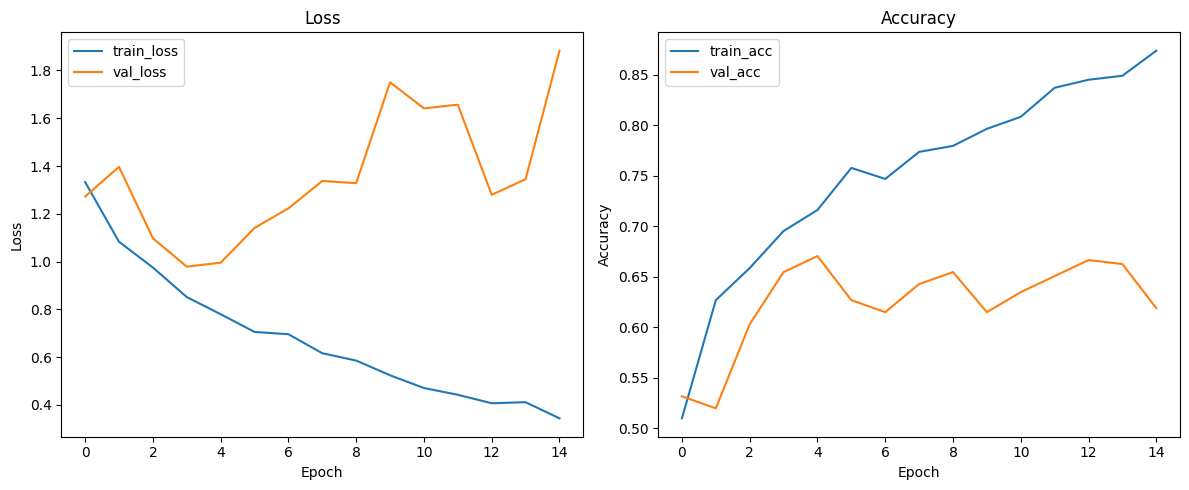

In [77]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [78]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 1.2615
Test accuracy: 0.5676


c:\Users\Šimon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Šimon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Šimon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

              precision    recall  f1-score   support

        bad1       0.56      0.50      0.53        18
        bad2       0.00      0.00      0.00        12
        bad3       0.50      0.55      0.52        20
        bad4       0.33      0.33      0.33        15
        good       0.66      0.83      0.73        46

    accuracy                           0.57       111
   macro avg       0.41      0.44      0.42       111
weighted avg       0.50      0.57      0.53       111



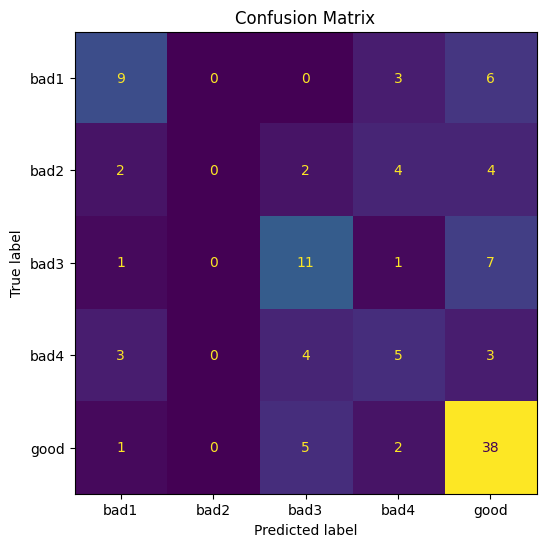

In [79]:
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = get_predictions(model, test_loader, device)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

In [80]:
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

torch.save(model.state_dict(), MODELS_DIR / "simple_cnn_casting.pth")
print("Model uložený.")

Model uložený.
